In [8]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define the quantum device
n_qubits = 4  # Adjust based on simulation speed (4-8 is usually fast)
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_projection_circuit(inputs, weights):
    # 1. Data Encoding: Map classical features to quantum state
    # We assume inputs are pre-processed to match n_qubits
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    # 2. Variational Layers: Trainable quantum gates
    # weights shape: (n_layers, n_qubits, 3) for StronglyEntangling
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    
    # 3. Measurement: Return expectation values for each qubit
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

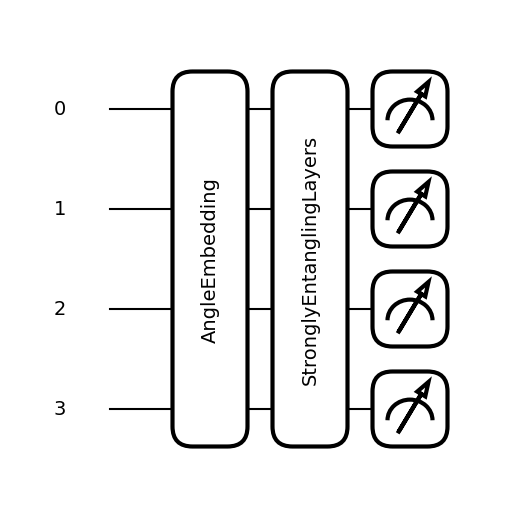

In [10]:
n_layers=2
fig, ax = qml.draw_mpl(quantum_projection_circuit)(np.random.random(n_qubits),np.random.random((n_layers,n_qubits,3)))
plt.show()